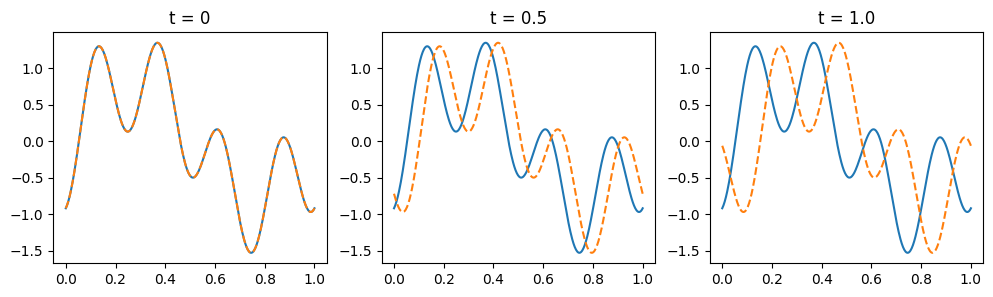

In [ ]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0); np.random.seed(0)

BETA, N_WAVES, N_MAX = 0.1, 3, 4
N_ICS_TRAIN, N_ICS_TEST = 80, 15

def make_ic(rng):
    ns   = rng.integers(1, N_MAX+1, size=N_WAVES)
    amps = rng.uniform(0, 1, size=N_WAVES)
    phis = rng.uniform(0, 2*np.pi, size=N_WAVES)
    return ns, amps, phis

def u0(x, ic):                        # x: torch or numpy, ic = (ns, amps, phis)
    ns, amps, phis = ic
    if isinstance(x, torch.Tensor):
        out = torch.zeros_like(x)
        for n, a, p in zip(ns, amps, phis):
            out = out + a*torch.sin(2*np.pi*n*x + p)
    else:
        out = sum(a*np.sin(2*np.pi*n*x + p) for n, a, p in zip(ns, amps, phis))
    return out

def u_exact(x, t, ic):                # periodic traveling wave
    return u0((x - BETA*t) % 1.0, ic)

rng = np.random.default_rng(42)
train_ics = [make_ic(rng) for _ in range(N_ICS_TRAIN)]
test_ics  = [make_ic(rng) for _ in range(N_ICS_TEST)]

xs = np.linspace(0, 1, 400)
ic0 = train_ics[0]
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, t in zip(ax, [0, 0.5, 1.0]):
    a.plot(xs, u0(xs, ic0)); a.plot(xs, u_exact(xs, t, ic0), '--')
    a.set_title(f't = {t}')
plt.show()

In [ ]:
class Encoder(nn.Module):             # lifting MLP (QPE / BPE / BVE all use this)
    def __init__(self, in_dim, m, hidden=64, layers=2):
        super().__init__()
        net, d = [], in_dim
        for _ in range(layers):
            net += [nn.Linear(d, hidden), nn.Tanh()]
            d = hidden
        net += [nn.Linear(d, m)]
        self.net = nn.Sequential(*net)
    def forward(self, x): return self.net(x)

class CAU(nn.Module):                 # cross-attention unit, Eq. (7)-(8)
    def __init__(self, m, heads=2):
        super().__init__()
        self.mha  = nn.MultiheadAttention(m, heads, batch_first=True)
        self.res  = nn.Linear(m, m)   # A_h mu_j in Eq. (8)
        self.mlp  = nn.Sequential(nn.Linear(m, 64), nn.Tanh(), nn.Linear(64, m))
    def forward(self, q, k, v):       # q: [B,1,m]  k,v: [B,L,m]
        att, _ = self.mha(q, k, v)    # softmax(QK^T/sqrt(m)) V — Eq. (7)
        return torch.tanh(self.res(q) + att)   # residual + activation — Eq. (8)

class PINTO(nn.Module):
    def __init__(self, m=64, heads=2, n_cau=1):
        super().__init__()
        self.qpe  = Encoder(2, m)     # query: (x, t)
        self.bpe  = Encoder(2, m)     # boundary coords
        self.bve  = Encoder(1, m)     # boundary VALUES  <-- the b enters here
        self.caus = nn.ModuleList([CAU(m, heads) for _ in range(n_cau)])
        self.out  = nn.Sequential(nn.Linear(m, 64), nn.Tanh(), nn.Linear(64, 1))
    def forward(self, X, Xb, b):
        q = self.qpe(X)               # [B,1,m]
        k = self.bpe(Xb)              # [B,L,m]
        v = self.bve(b)               # [B,L,m]
        for cau in self.caus:
            q = cau(q, k, v)
        return self.out(q).squeeze(-1)

In [ ]:
def physics_residual_loss(model, ics_batch, Xb, b, n_col=256):
    B = len(ics_batch)
    X  = torch.rand(B, n_col, 2, device=device, requires_grad=True)  # (x,t) collocation pts
    Xr = X.reshape(B*n_col, 1, 2)
    u  = model(Xr, Xb.repeat_interleave(n_col, 0), b.repeat_interleave(n_col, 0))
    u  = u.reshape(B, n_col)
    g  = torch.autograd.grad(u.sum(), X, create_graph=True)[0]
    res = g[..., 1] + BETA*g[..., 0]          # u_t + beta*u_x  -> should be 0
    return (res**2).mean()

def boundary_loss(model, Xb, b):
    B, L, _ = Xb.shape
    pred = model(Xb.reshape(-1, 1, 2), Xb.repeat_interleave(L, 0), b.repeat_interleave(L, 0)).reshape(b.shape)
    return ((pred - b)**2).mean()

def make_tokens(ics_batch, L=60):
    B = len(ics_batch)
    x  = torch.rand(B, L, 1, device=device)
    Xb = torch.cat([x, torch.zeros_like(x)], dim=-1)          # t = 0 line
    b  = torch.stack([u0(Xb[i,:,0].cpu(), ic) for i, ic in enumerate(ics_batch)])
    return Xb.to(device), b.unsqueeze(-1).to(device)

model = PINTO(n_cau=1).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-4)         # higher lr since fewer epochs
LAM2  = 10.0                                                  # boundary weight (tune 1-100)
history = {'epoch': [], 'physics': [], 'boundary': []}

for epoch in range(25000):
    ics = [train_ics[i] for i in np.random.choice(N_ICS_TRAIN, 4, replace=False)]
    Xb, b = make_tokens(ics)
    lp = physics_residual_loss(model, ics, Xb, b)
    lb = boundary_loss(model, Xb, b)
    loss = lp + LAM2*lb
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 100 == 0:                          # <-- ADD these 4 lines
        history['epoch'].append(epoch)
        history['physics'].append(lp.item())
        history['boundary'].append(lb.item())
    if epoch % 200 == 0:
        print(f'{epoch:5d}  physics {lp.item():.2e}  bnd(λ·lb) {(LAM2*lb).item():.2e}')

np.save('history.npy', history, allow_pickle=True)

    0  physics 9.50e-04  bnd(λ·lb) 3.77e+00
  200  physics 1.03e-03  bnd(λ·lb) 2.09e+00
  400  physics 6.49e-04  bnd(λ·lb) 4.23e+00
  600  physics 1.28e-03  bnd(λ·lb) 3.04e+00
  800  physics 3.59e-04  bnd(λ·lb) 1.25e+00
 1000  physics 1.05e-03  bnd(λ·lb) 4.07e+00
 1200  physics 3.16e-04  bnd(λ·lb) 3.39e+00
 1400  physics 2.81e-04  bnd(λ·lb) 5.33e+00
 1600  physics 2.32e-04  bnd(λ·lb) 1.81e+00
 1800  physics 8.05e-04  bnd(λ·lb) 5.91e+00
 2000  physics 3.40e-04  bnd(λ·lb) 4.24e+00
 2200  physics 4.25e-04  bnd(λ·lb) 7.30e+00
 2400  physics 8.01e-04  bnd(λ·lb) 5.68e+00
 2600  physics 3.46e-04  bnd(λ·lb) 2.33e+00
 2800  physics 2.72e-04  bnd(λ·lb) 3.57e+00
 3000  physics 1.14e-03  bnd(λ·lb) 7.85e+00
 3200  physics 4.52e-04  bnd(λ·lb) 4.81e+00
 3400  physics 2.50e-04  bnd(λ·lb) 2.60e+00
 3600  physics 2.64e-04  bnd(λ·lb) 2.27e+00
 3800  physics 1.31e-04  bnd(λ·lb) 4.34e+00
 4000  physics 2.04e-04  bnd(λ·lb) 4.27e+00
 4200  physics 1.33e-03  bnd(λ·lb) 2.18e+00
 4400  physics 9.84e-04  bnd(λ·l

In [ ]:
def rel_error(model, ic, n=101):
    xs = torch.linspace(0, 1, n, device=device)
    ts = torch.linspace(0, 1, n, device=device)
    gx, gt = torch.meshgrid(xs, ts, indexing='ij')
    X = torch.stack([gx, gt], -1).reshape(-1, 1, 2)
    Xb, b = make_tokens([ic])

    # Repeat boundary tokens to match the batch dimension of query X which has size n*n
    num_queries = X.shape[0]
    pred = model(X, Xb.expand(num_queries, -1, -1), b.expand(num_queries, -1, -1))
    pred = pred.reshape(n, n).cpu().detach().numpy()

    true = u_exact(xs.cpu().numpy()[:, None].repeat(n, 1),
                   ts.cpu().numpy()[None, :].repeat(n, 0), ic)
    return np.mean(np.abs(true - pred) / (1 + np.abs(true))), pred, true

errs = []
for ic in test_ics:                        # UNSEEN initial conditions
    e, pred, true = rel_error(model, ic)
    errs.append(e)
print(f'Mean relative error on {len(test_ics)} UNSEEN ICs: {100*np.mean(errs):.2f}%')
seen_errs = [rel_error(model, ic)[0] for ic in train_ics[:5]]   # ICs the model trained on
print(f'Seen:   {100*np.mean(seen_errs):.1f}%')
print(f'Unseen: {100*np.mean(errs):.1f}%')

Mean relative error on 15 UNSEEN ICs: 6.25%
Seen:   4.9%
Unseen: 6.3%


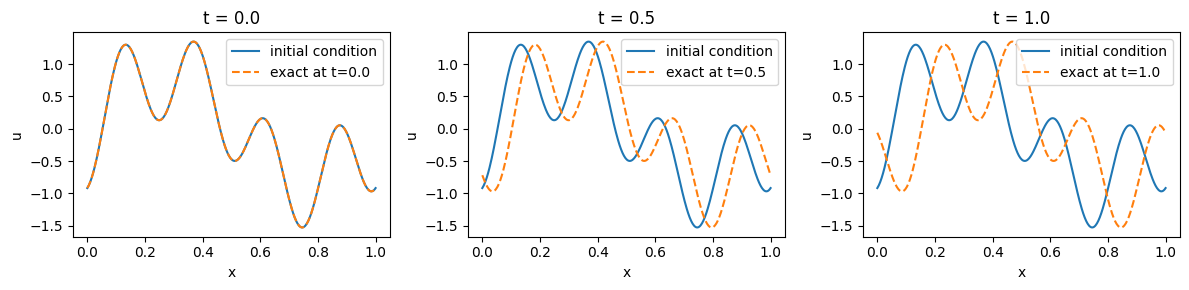

In [ ]:
ic = train_ics[0]
xs = np.linspace(0, 1, 400)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, t in zip(axes, [0.0, 0.5, 1.0]):
    ax.plot(xs, u0(xs, ic), label='initial condition')
    ax.plot(xs, u_exact(xs, t, ic), '--', label=f'exact at t={t}')
    ax.set_xlabel('x'); ax.set_ylabel('u'); ax.set_title(f't = {t}'); ax.legend()
plt.tight_layout()
plt.savefig('data_sanity.png', dpi=150)

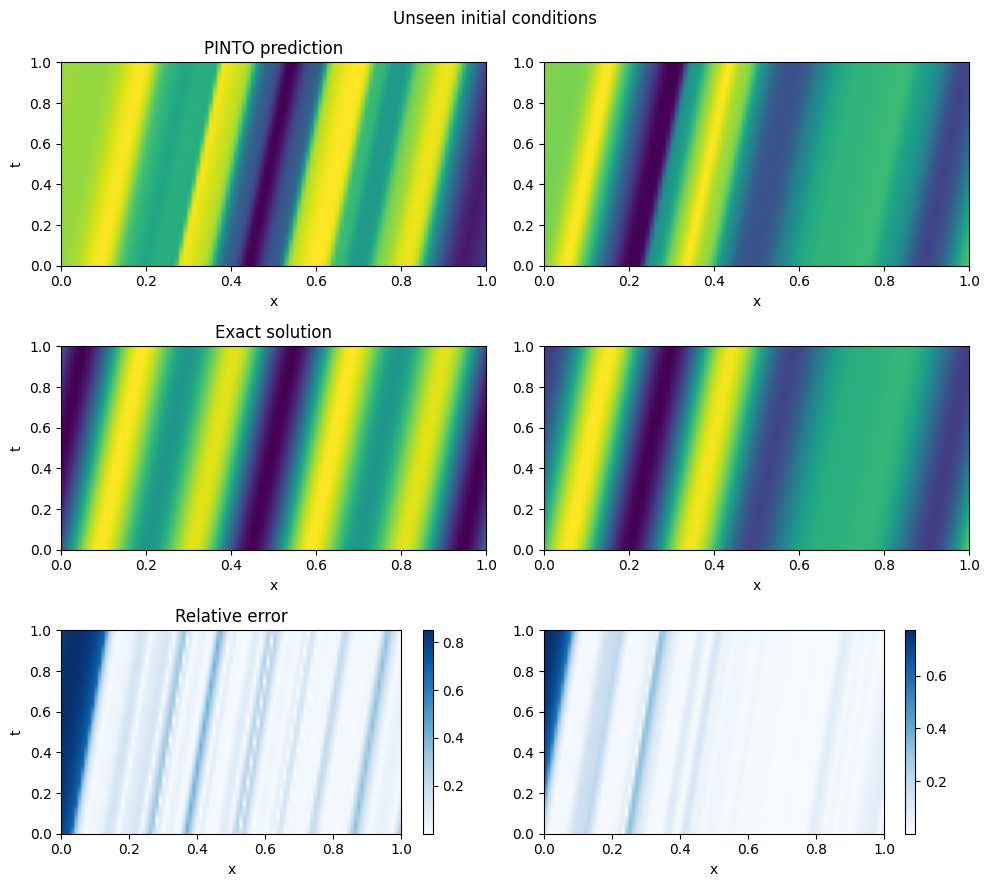

In [ ]:
def eval_grid(model, ic, n=101):
    xs = torch.linspace(0, 1, n, device=device)
    ts = torch.linspace(0, 1, n, device=device)
    gx, gt = torch.meshgrid(xs, ts, indexing='ij')
    X = torch.stack([gx, gt], -1).reshape(-1, 1, 2)
    Xb, b = make_tokens([ic])
    pred = model(X, Xb.expand(X.shape[0], -1, -1),
                 b.expand(X.shape[0], -1, -1)).reshape(n, n).cpu().detach().numpy()
    true = u_exact(xs.cpu().numpy()[:, None].repeat(n, 1),
                   ts.cpu().numpy()[None, :].repeat(n, 0), ic)
    return pred, true, np.abs(true - pred) / (1 + np.abs(true))

fig, axes = plt.subplots(3, 2, figsize=(10, 9))
for col, ic in enumerate(test_ics[:2]):        # two UNSEEN ICs
    pred, true, err = eval_grid(model, ic)
    im0 = axes[0, col].imshow(pred.T, origin='lower', extent=[0,1,0,1], aspect='auto')
    axes[0, col].set_title('PINTO prediction' if col==0 else '')
    im1 = axes[1, col].imshow(true.T, origin='lower', extent=[0,1,0,1], aspect='auto')
    axes[1, col].set_title('Exact solution' if col==0 else '')
    im2 = axes[2, col].imshow(err.T, origin='lower', extent=[0,1,0,1], aspect='auto',
                              cmap='Blues')
    axes[2, col].set_title('Relative error' if col==0 else '')
    for ax in axes[:, col]: ax.set_xlabel('x')
    plt.colorbar(im2, ax=axes[2, col])         # colorbar only on error rows
axes[0, 0].set_ylabel('t'); axes[1, 0].set_ylabel('t'); axes[2, 0].set_ylabel('t')
plt.suptitle('Unseen initial conditions')
plt.tight_layout()
plt.savefig('unseen_predictions.png', dpi=150)

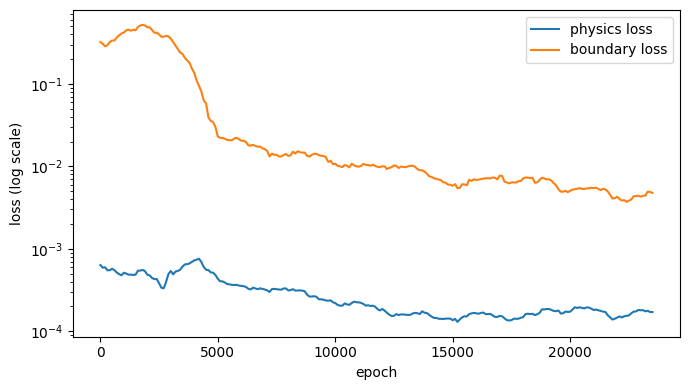

In [ ]:
import numpy as np, matplotlib.pyplot as plt

history = np.load('history.npy', allow_pickle=True).item()

def smooth(y, k=15):                     # moving average to tame the noise
    return np.convolve(y, np.ones(k)/k, mode='valid')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(history['epoch'][:len(smooth(history['physics']))],
            smooth(history['physics']), label='physics loss')
ax.semilogy(history['epoch'][:len(smooth(history['boundary']))],
            smooth(history['boundary']), label='boundary loss')
ax.set_xlabel('epoch'); ax.set_ylabel('loss (log scale)'); ax.legend()
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()

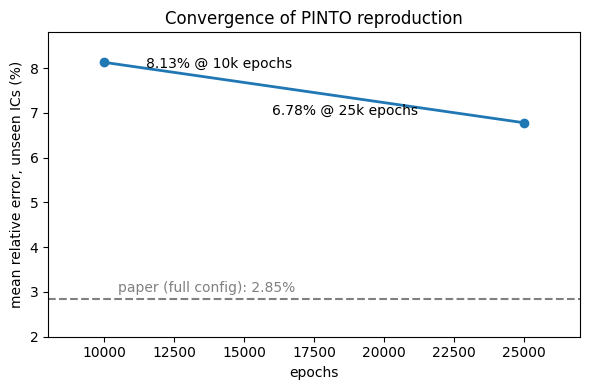

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([10000, 25000], [8.13, 6.78], 'o-', linewidth=2, markersize=6)

ax.axhline(y=2.85, color='gray', linestyle='--', linewidth=1.5)
ax.text(10500, 3.0, 'paper (full config): 2.85%', color='gray', fontsize=10)

ax.annotate('8.13% @ 10k epochs', xy=(10000, 8.13),
            xytext=(11500, 8.0), fontsize=10)
ax.annotate('6.78% @ 25k epochs', xy=(25000, 6.78),
            xytext=(16000, 6.95), fontsize=10)

ax.set_xlabel('epochs')
ax.set_ylabel('mean relative error, unseen ICs (%)')
ax.set_title('Convergence of PINTO reproduction')
ax.set_xlim(8000, 27000)          # padding so points aren't clipped
ax.set_ylim(2.0, 8.8)             # includes the 2.85 reference line

plt.tight_layout()
plt.savefig('convergence.png', dpi=150)
plt.show()